**Gambler's Ruin**

*Problem Statement*
A gambler walks into a casino with $k, and the casino has $(n-k). The total money in play is $n. Each round, the gambler wins $1 with probability p and loses $1 with probability q (=1-p). The game ends when either of the two things happens:
- The gambler reaches $0 → ruined
- The gambler reaches $n → wins everything (the casino is ruined)

The question is: **what is the probability that the gambler goes broke?**

*The Paradox:*  
The intuitive answer is that if the game is fair (p = 0.5), a richer starting stack should give you a meaningful advantage. And while this is partially true, the actual numbers are far more brutal than intuition suggests.
Even in a perfectly fair game, your probability of winning is simply k/N. If you have $10 and your opponent has $90, you only win 10% of the time, despite playing a fair coin flip. The house does not need an edge to ruin you. A deep enough pocket on the other side is sufficient.
Now consider what happens when p < 0.5. A tiny unfair edge, like the kind a casino holds, does not just reduce your winning chances a little. It makes ruin almost certain, especially over a long enough game. The probability of survival decays exponentially with the opponent's wealth, and for any finite k against a sufficiently wealthy opponent, the gambler is essentially already ruined.
So why does a fair game still lead to almost certain ruin when one player is much richer? And why does even a small bias make things so much worse so quickly? This is what makes Gambler's Ruin one of the starkest results in probability theory.  

*The Solution:*  
The ruin probability has a clean closed form. For p ≠ 0.5, the probability that a gambler starting at k ruins before reaching N is:
P(ruin | start at k) = [ (q/p)^k − (q/p)^N ] / [ 1 − (q/p)^N ]
For the fair case (p = 0.5), this simplifies to 1 − k/N, meaning the survival probability is exactly k/N.
Duration tells an equally striking story. Even when you are destined to lose, the game can drag on for an unexpectedly long time, thus giving the illusion of a close contest before the inevitable outcome.  

**What is this simulation about?**  
This Python code simulates a large number of independent Gambler's Ruin games and studies how they play out across three visualisations. The ruin probability plot shows how the probability of going broke changes with starting wealth k, comparing the simulated outcomes against the closed-form theoretical curve, in which the two lines sit almost exactly on top of each other, confirming the formula. The fairness plot shows how the ruin probability curve shifts as p varies, such that a fair game (p = 0.5) gives a clean linear relationship, while even a slight unfair edge bends the curve sharply upward, making ruin near-certain for almost any starting capital. Finally, the trajectories plot traces a handful of individual games as wealth evolves round by round -- each line a jagged path that either climbs to N or collapses to 0, making the randomness and the finality of ruin visible at once.

In [20]:
import random
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(42)

**Defining one game**

In [21]:
def play(k, n, p):
    wealth = k                              #defining the starting wealth
    trajectory = [wealth]

    while wealth > 0 and wealth < n:        #games stops if either the casino wins or the gambler wins 
        if random.random() < p:             #we choose the random.random() function to generate a random number between 0 and 1
            wealth += 1                     #the gambler wins a round if the randomly chosen number is <p
        else:
            wealth -= 1                     #otherwise, the gambler loses this round
        trajectory.append(wealth)           #storing the trajectory

    result = (wealth == 0)                  #checking if the gambler was ruined or not
    return result, trajectory               #returning the final values

**Defining the theoretical probabilities**

In [22]:
def theoretical_prob(k, n, p):
    if p == 0.5:
        return 1 - k / n                        #theoretical formula for p = q = 0.5
    else:
        r = (1 - p) / p                         #ratio
        return (1 - r**k) / (1 - r**n)          #theoretical formula for p != q

**Setting the parameters for the Simulation**  
Feel free to change these and explore as much as you can!

In [23]:
k = 10          #gambler's starting wealth
n = 100         #total pot (gambler + casino)
p = 0.4         #probability of winning each round
trials = 10000  #number of games to simulate

**Running the simulation**

In [24]:
ruin = 0
sample = []

for i in range(trials):
    res, traj = play(k, n, p)
    if res:
        ruin += 1
    if i < 10:
        sample.append(traj)

**Printing the results**

In [25]:
expt_prob   = ruin / trials
theory_prob = theoretical_prob(k, n, p)

print(f"Starting wealth: ${k} of ${n} total, p = {p}")
print(f"Simulated ruin probability: {expt_prob*100:.2f}%")
print(f"Theoretical ruin probability:  {theory_prob*100:.2f}%")

Starting wealth: $10 of $100 total, p = 0.4
Simulated ruin probability: 100.00%
Theoretical ruin probability:  0.00%


**Visualising the results**

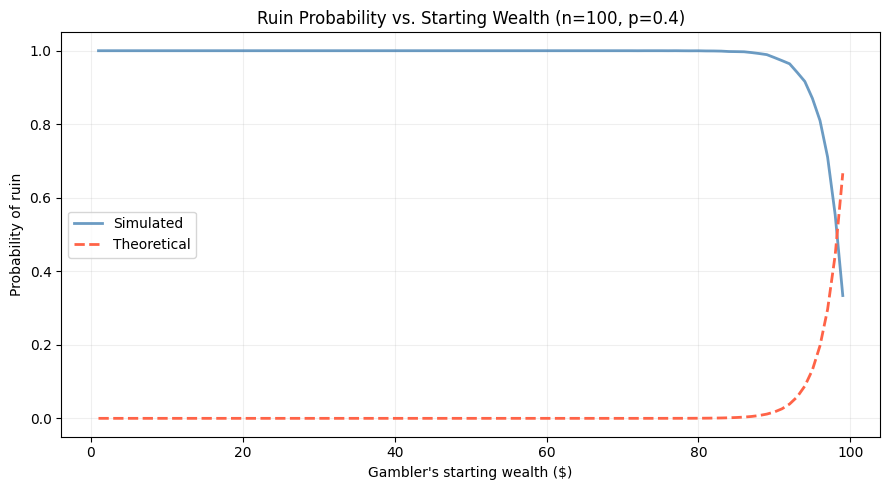

In [26]:
starting_wealth = [i for i in range(1, n)]
ruin_prob = []
theory_ruin_prob = []

for i in starting_wealth:
    ruins = sum(play(i, n, p)[0] for _ in range(trials))
    ruin_prob.append(ruins / trials)
    theory_ruin_prob.append(theoretical_prob(i, n, p))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(starting_wealth, 
        ruin_prob,    
        color='steelblue', 
        linewidth=2, 
        label='Simulated', 
        alpha=0.8
        )

ax.plot(starting_wealth, 
        theory_ruin_prob, 
        color='tomato',    
        linewidth=2, 
        label='Theoretical', 
        linestyle='--'
        )

ax.set_xlabel("Gambler's starting wealth ($)")
ax.set_ylabel("Probability of ruin")
ax.set_title(f"Ruin Probability vs. Starting Wealth (n={n}, p={p})")

ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

As you can clearly see, the two lines sit almost exactly on top of each other. Whenever they don't, it's simulation noise.

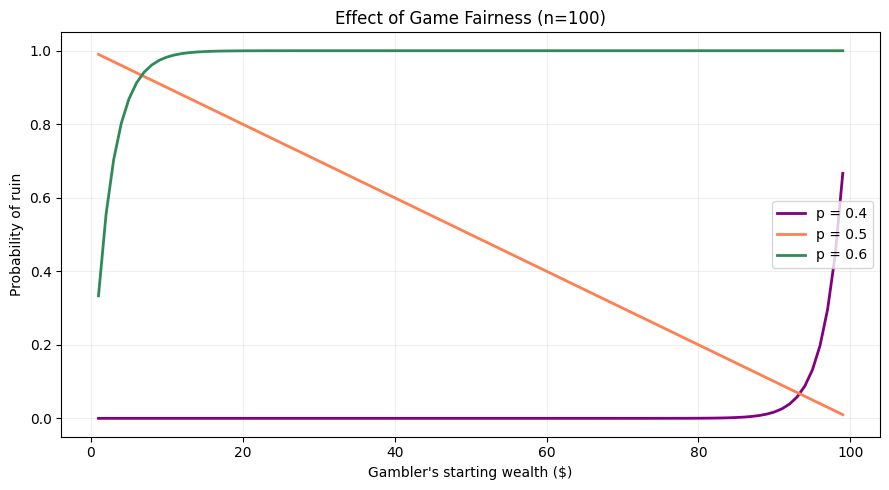

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
c = {0.4: 'purple', 0.5: 'coral', 0.6: 'seagreen'}

for prob in [0.4, 0.5, 0.6]:
    theory = [theoretical_prob(i, n, prob) for i in starting_wealth]
    ax.plot(starting_wealth, 
            theory, 
            color = c[prob],
            linewidth = 2,
            label = f'p = {prob}'
            )

ax.set_xlabel("Gambler's starting wealth ($)")
ax.set_ylabel("Probability of ruin")
ax.set_title(f"Effect of Game Fairness (n={n})") 

ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Even a tiny edge (p = 0.6 vs p = 0.5) dramatically flattens the ruin curve. This is why casinos only need a slight house edge, and the long run does the rest. This concept is widely used by casinos all over the world to stay profitable and it answers the famous question "Why do casinos always win?". It's not really about how much is at stake. Well, it's not *just* about that. The bigger factor involved here is how long does a gambler play. The odds of a gambler getting ruined are significantly high (almost 100%) if the gambler plays for long enough.

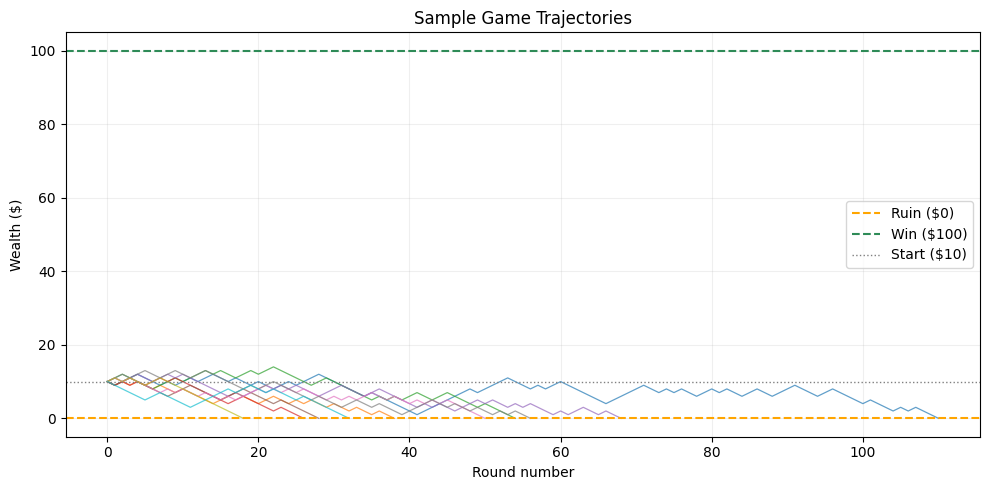

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

for t in sample:
    ax.plot(range(len(t)), 
            t, 
            alpha=0.7, 
            linewidth=0.9
            )

ax.axhline(y=0, 
           color='orange',   
           linestyle='--', 
           linewidth=1.5, 
           label='Ruin ($0)'
           )

ax.axhline(y=n, 
           color='seagreen', 
           linestyle='--', 
           linewidth=1.5, 
           label=f'Win (${n})'
           )

ax.axhline(y=k, 
           color='gray',     
           linestyle=':',  
           linewidth=1,   
           label=f'Start (${k})'
           )

ax.set_xlabel('Round number')
ax.set_ylabel('Wealth ($)')
ax.set_title("Sample Game Trajectories")

ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Again, this graph clearly proves that no matter what is the starting amount, or the probability of winning/ruining, the gambler will eventually go bankrupt/get ruined if they play long enough.